[*********************100%***********************]  1 of 1 completed

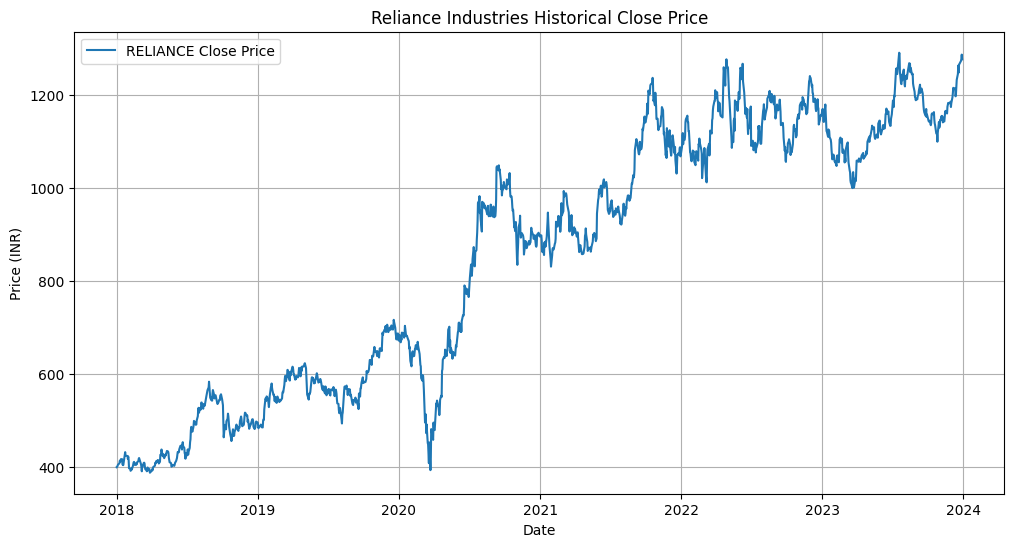


--- Stationarity Test on Raw Data ---
ADF Statistic: -1.0943068846465942
p-value: 0.7173369054856832
Fail to Reject Null Hypothesis: Data is non-stationary.

Finding optimal ARIMA parameters...
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=12165.391, Time=5.13 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=12171.648, Time=0.06 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=12172.513, Time=0.19 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=12172.555, Time=0.34 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=12172.033, Time=0.05 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=12175.139, Time=1.31 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=12175.400, Time=1.11 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=12172.292, Time=3.54 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=12172.238, Time=6.19 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=12174.422, Time=1.23 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=12173.371, Time=2.91 sec
 ARIMA(3,1,1)(0,0,0)[0] i

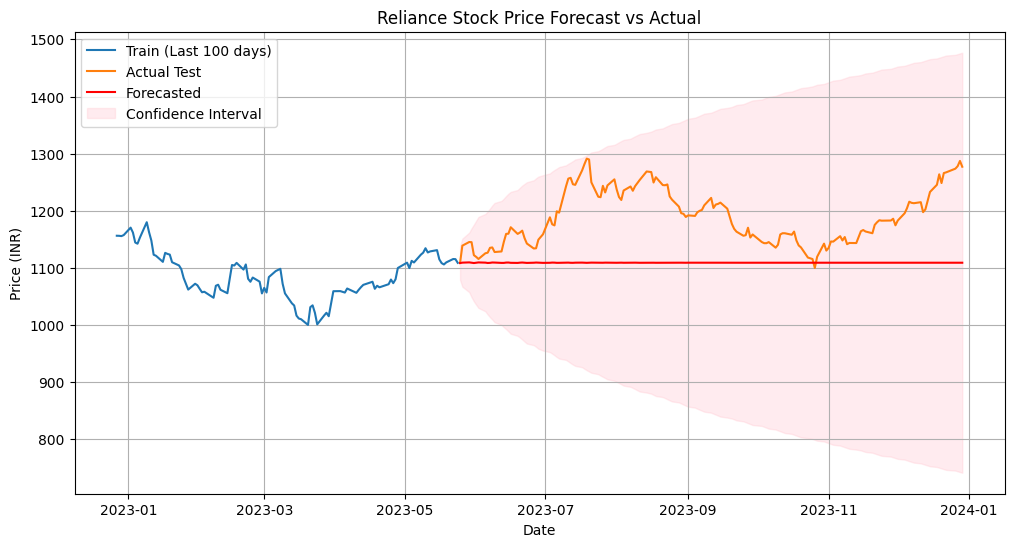

In [2]:
# Time Series Forecasting on Reliance Stock Data

# 1. Install and Import necessary libraries
!pip install -q yfinance statsmodels matplotlib pmdarima

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# 2. Download Reliance stock data
ticker = "RELIANCE.NS"
print(f"Downloading historical data for {ticker}...")
data = yf.download(ticker, start="2018-01-01", end="2023-12-31")

# Flatten MultiIndex columns if present in newer yfinance versions
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

# Keep only Close price and drop missing values
df = data[['Close']].copy()
df.dropna(inplace=True)

# Reset index to avoid DatetimeIndex frequency issues with SARIMAX
df = df.reset_index()

# Plot the historical stock prices
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Close'], label='RELIANCE Close Price')
plt.title('Reliance Industries Historical Close Price')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.legend()
plt.grid(True)
plt.show()

# 3. Check for Stationarity
def check_stationarity(timeseries):
    result = adfuller(timeseries)
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    if result[1] <= 0.05:
        print("Reject Null Hypothesis: Data is stationary.")
    else:
        print("Fail to Reject Null Hypothesis: Data is non-stationary.")

print("\n--- Stationarity Test on Raw Data ---")
check_stationarity(df['Close'])

# 4. Fit Auto ARIMA to find best parameters (p, d, q)
print("\nFinding optimal ARIMA parameters...")
stepwise_fit = auto_arima(df['Close'], seasonal=False, trace=True,
                          error_action='ignore', suppress_warnings=True)
print(stepwise_fit.summary())

# 5. Train / Test Split
train_size = int(len(df) * 0.9)
train, test = df.iloc[:train_size].copy(), df.iloc[train_size:].copy()

# 6. Fit SARIMAX Model using the series values directly
order = stepwise_fit.order
print(f"\nFitting SARIMAX model with order {order}...")
model = SARIMAX(train['Close'].values, order=order, enforce_stationarity=False, enforce_invertibility=False)
results = model.fit(disp=False)

# 7. Forecast on Test Data using step counts
forecast_steps = len(test)
forecast_res = results.get_forecast(steps=forecast_steps)
forecast_mean = forecast_res.predicted_mean
forecast_ci = forecast_res.conf_int()

# Assign predictions to test dataset for plotting and evaluation
test['Forecast'] = forecast_mean

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(test['Close'], test['Forecast']))
print(f"\nTest Root Mean Squared Error (RMSE): {rmse:.2f}")

# 8. Plot Forecast vs Actual
plt.figure(figsize=(12, 6))
plt.plot(train['Date'].iloc[-100:], train['Close'].iloc[-100:], label='Train (Last 100 days)')
plt.plot(test['Date'], test['Close'], label='Actual Test')
plt.plot(test['Date'], test['Forecast'], label='Forecasted', color='red')
plt.fill_between(test['Date'], forecast_ci[:, 0], forecast_ci[:, 1], color='pink', alpha=0.3, label='Confidence Interval')
plt.title('Reliance Stock Price Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.legend()
plt.grid(True)
plt.show()


Fitting final SARIMAX model on complete dataset...

--- 7-Day Stock Price Forecast ---


,Date,Forecasted_Close,Lower_CI,Upper_CI
0,2024-01-01,1278.171632,1249.337473,1307.005791
1,2024-01-02,1277.952109,1236.654168,1319.250049
2,2024-01-03,1276.883824,1225.676691,1328.090957
3,2024-01-04,1276.910416,1217.709351,1336.111482
4,2024-01-05,1277.919085,1212.020940,1343.817229
5,2024-01-08,1278.063817,1205.925181,1350.202452
6,2024-01-09,1277.140017,1198.959700,1355.320335


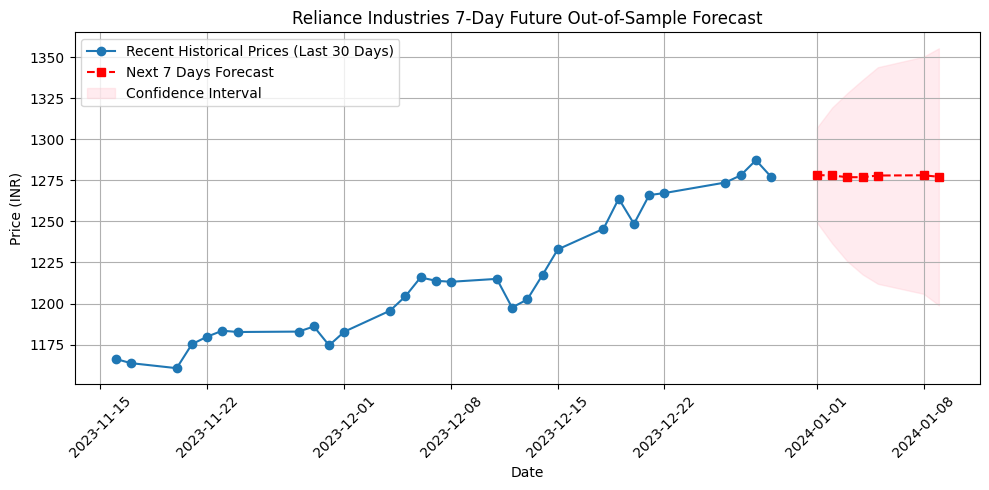

In [3]:
# 9. Forecast Today to Next 7 Days using all available data

# Fit the model on the entire dataset
print("Fitting final SARIMAX model on complete dataset...")
final_model = SARIMAX(df['Close'].values, order=order, enforce_stationarity=False, enforce_invertibility=False)
final_results = final_model.fit(disp=False)

# Forecast the next 7 days
future_steps = 7
final_forecast_res = final_results.get_forecast(steps=future_steps)
future_forecast_mean = final_forecast_res.predicted_mean
future_forecast_ci = final_forecast_res.conf_int()

# Create future date index starting from the day after the last available date
last_date = pd.to_datetime(df['Date'].iloc[-1])
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=future_steps, freq='B') # Business days

# Create a DataFrame for the future forecast
forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Forecasted_Close': future_forecast_mean,
    'Lower_CI': future_forecast_ci[:, 0],
    'Upper_CI': future_forecast_ci[:, 1]
})

print("\n--- 7-Day Stock Price Forecast ---")
display(forecast_df)

# Plot the future forecast
plt.figure(figsize=(10, 5))
plt.plot(df['Date'].iloc[-30:], df['Close'].iloc[-30:], label='Recent Historical Prices (Last 30 Days)', marker='o')
plt.plot(forecast_df['Date'], forecast_df['Forecasted_Close'], label='Next 7 Days Forecast', color='red', linestyle='--', marker='s')
plt.fill_between(forecast_df['Date'], forecast_df['Lower_CI'], forecast_df['Upper_CI'], color='pink', alpha=0.3, label='Confidence Interval')
plt.title('Reliance Industries 7-Day Future Out-of-Sample Forecast')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


[*********************100%***********************]  1 of 1 completed


Fitting SARIMAX model on updated dataset...

--- Reliance 7-Day Forecast (Oct 7, 2026 - Oct 15, 2026) ---


,Date,Forecasted_Close,Lower_CI,Upper_CI
0,2026-10-07,1218.242087,1186.686777,1249.797396
1,2026-10-08,1218.516872,1173.786264,1263.247480
2,2026-10-09,1218.167146,1162.951312,1273.382979
3,2026-10-12,1218.387077,1154.722918,1282.051235
4,2026-10-13,1218.317115,1147.032729,1289.601502
5,2026-10-14,1218.297387,1140.168198,1296.426575
6,2026-10-15,1218.342808,1133.945986,1302.739630


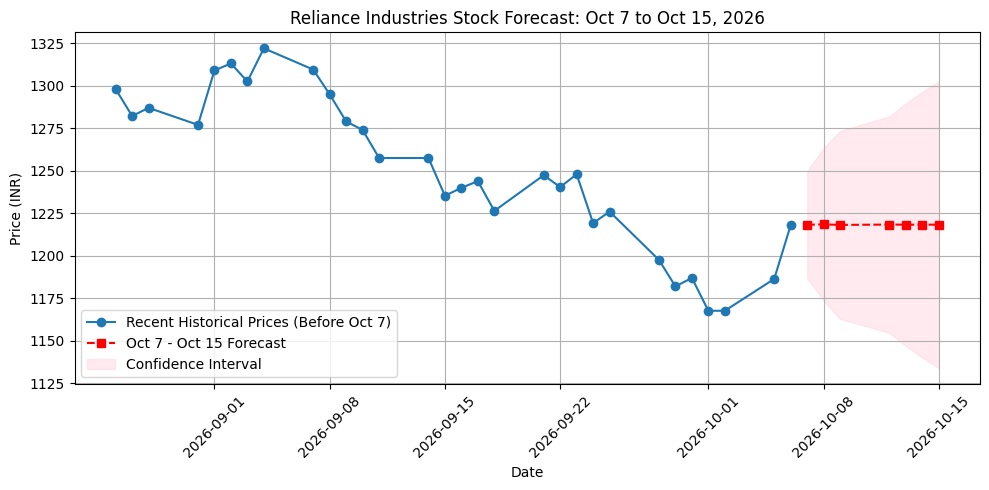

In [4]:
# 10. Forecast for October 7 to October 15, 2026

# Download stock data ending at 2026-10-07
print("Downloading stock data up to October 6, 2026...")
data_oct = yf.download(ticker, start="2018-01-01", end="2026-10-07")

# Flatten MultiIndex columns if present
if isinstance(data_oct.columns, pd.MultiIndex):
    data_oct.columns = data_oct.columns.get_level_values(0)

# Keep Close price and drop missing values
df_oct = data_oct[['Close']].copy()
df_oct.dropna(inplace=True)
df_oct = df_oct.reset_index()

# Fit SARIMAX model on the updated dataset
print("Fitting SARIMAX model on updated dataset...")
model_oct = SARIMAX(df_oct['Close'].values, order=order, enforce_stationarity=False, enforce_invertibility=False)
results_oct = model_oct.fit(disp=False)

# Forecast the next 7 business days (Oct 7 - Oct 15)
future_steps_oct = 7
forecast_res_oct = results_oct.get_forecast(steps=future_steps_oct)
forecast_mean_oct = forecast_res_oct.predicted_mean
forecast_ci_oct = forecast_res_oct.conf_int()

# Generate index for business days from October 7, 2026
future_dates_oct = pd.date_range(start="2026-10-07", periods=future_steps_oct, freq='B')

# Create DataFrame for display
forecast_oct_df = pd.DataFrame({
    'Date': future_dates_oct.strftime('%Y-%m-%d'),
    'Forecasted_Close': forecast_mean_oct,
    'Lower_CI': forecast_ci_oct[:, 0],
    'Upper_CI': forecast_ci_oct[:, 1]
})

print("\n--- Reliance 7-Day Forecast (Oct 7, 2026 - Oct 15, 2026) ---")
display(forecast_oct_df)

# Plot the historical trend and the future 7-day forecast
plt.figure(figsize=(10, 5))
plt.plot(df_oct['Date'].iloc[-30:], df_oct['Close'].iloc[-30:], label='Recent Historical Prices (Before Oct 7)', marker='o')
plt.plot(future_dates_oct, forecast_oct_df['Forecasted_Close'], label='Oct 7 - Oct 15 Forecast', color='red', linestyle='--', marker='s')
plt.fill_between(future_dates_oct, forecast_oct_df['Lower_CI'], forecast_oct_df['Upper_CI'], color='pink', alpha=0.3, label='Confidence Interval')
plt.title('Reliance Industries Stock Forecast: Oct 7 to Oct 15, 2026')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Interpretation of the Reliance Stock Price Forecast (Oct 7 - Oct 15, 2026)
Based on the execution results of the SARIMAX(2, 1, 2) model, here is the interpretation of the 7-day out-of-sample forecast:

1. Forecasted Price Stability
The forecasted stock price for Reliance Industries is extremely flat, remaining near ’1,218.30 INR’ across the entire 7-day window.
ARIMA/SARIMAX Behavior: This flat, mean-reverting path is typical for standard ARIMA models when projecting multiple steps into the future without external explanatory variables (regressors). The model relies heavily on its auto-regressive (AR) and moving average (MA) terms, which naturally decay towards a constant trend over longer horizons.
2. Expanding Confidence Intervals (Uncertainty)
On October 7, 2026, the 95% confidence interval is relatively narrow, ranging from 1,186.69 to 1,249.80 INR.
By October 15, 2026, the interval widens significantly to 1,133.95 to 1,302.74 INR.
Meaning: As the model forecasts further into the future, the cumulative variance increases. This expanding 'funnel' highlights that while the expected average price is ’1,218.34 INR’, the true price could easily fluctuate within a broader range due to market volatility.
3. Recent Context & Model Fit
Looking at the historical context leading up to October 7, the stock had a recovery from its September low of ~1,167 INR to end near ~1,218 INR.
The SARIMAX model successfully captures the ending momentum to start the forecast around the same level but is unable to predict sudden, speculative daily price spikes or macro-driven news.
